# Trader Performance vs Market Sentiment Analysis

## Part A - Data preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")



Libraries imported successfully!


In [2]:
sentiment = pd.read_csv("../data/fear_greed_index.csv")
trader = pd.read_csv("../data/historical_data.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [3]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
print("Sentiment Dataset Shape:", sentiment.shape)
print("Trader Dataset Shape:", trader.shape)

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)


## Data Understanding

In [6]:
sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [7]:
trader.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

## Missing Values

In [8]:
print("Sentiment Dataset")
print(sentiment.isnull().sum())

print("\nTrader Dataset")
print(trader.isnull().sum())

Sentiment Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


## Duplicate Records

In [9]:
print("Sentiment Duplicates:", sentiment.duplicated().sum())

print("Trader Duplicates:", trader.duplicated().sum())

Sentiment Duplicates: 0
Trader Duplicates: 0


## If Duplicate values exists

In [10]:
sentiment = sentiment.drop_duplicates()

trader = trader.drop_duplicates()

In [11]:
print(sentiment.shape)

print(trader.shape)

(2644, 4)
(211224, 16)


In [12]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [13]:
print(trader.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [14]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## Data Conversion

In [15]:
trader[['Timestamp']].head()

,Timestamp
0,1.730000e+12
1,1.730000e+12
2,1.730000e+12
3,1.730000e+12
4,1.730000e+12


In [16]:
trader['Timestamp'] = pd.to_datetime(trader['Timestamp'], unit='ms')

In [17]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [18]:
trader['date'] = trader['Timestamp'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [19]:
print(sentiment[['date']].head())

print(trader[['Timestamp','date']].head())

         date
0  2018-02-01
1  2018-02-02
2  2018-02-03
3  2018-02-04
4  2018-02-05
            Timestamp        date
0 2024-10-27 03:33:20  2024-10-27
1 2024-10-27 03:33:20  2024-10-27
2 2024-10-27 03:33:20  2024-10-27
3 2024-10-27 03:33:20  2024-10-27
4 2024-10-27 03:33:20  2024-10-27


In [20]:
print("Sentiment Date Range")
print("Minimum:", sentiment['date'].min())
print("Maximum:", sentiment['date'].max())

print("\nTrader Date Range")
print("Minimum:", trader['date'].min())
print("Maximum:", trader['date'].max())

Sentiment Date Range
Minimum: 2018-02-01
Maximum: 2025-05-02

Trader Date Range
Minimum: 2023-03-28
Maximum: 2025-06-15


## Merge Datasets

In [21]:
merged = pd.merge(
    trader,
    sentiment,
    on='date',
    how='left'
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed


In [22]:
merged = pd.merge(
    trader,
    sentiment[['date', 'classification', 'value']],
    on='date',
    how='left'
)

In [23]:
merged[['date', 'classification', 'value']].head(10)

,date,classification,value
0,2024-10-27,Greed,74.0
1,2024-10-27,Greed,74.0
2,2024-10-27,Greed,74.0
3,2024-10-27,Greed,74.0
4,2024-10-27,Greed,74.0
5,2024-10-27,Greed,74.0
6,2024-10-27,Greed,74.0
7,2024-10-27,Greed,74.0
8,2024-10-27,Greed,74.0
9,2024-10-27,Greed,74.0


In [24]:
print("Missing sentiment values:", merged['classification'].isnull().sum())

Missing sentiment values: 26961


In [25]:
merged = merged.dropna(subset=['classification'])

print("Merged dataset shape:", merged.shape)

Merged dataset shape: (184263, 19)


In [26]:
merged.info()

<class 'pandas.DataFrame'>
Index: 184263 entries, 0 to 210767
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           184263 non-null  str           
 1   Coin              184263 non-null  str           
 2   Execution Price   184263 non-null  float64       
 3   Size Tokens       184263 non-null  float64       
 4   Size USD          184263 non-null  float64       
 5   Side              184263 non-null  str           
 6   Timestamp IST     184263 non-null  str           
 7   Start Position    184263 non-null  float64       
 8   Direction         184263 non-null  str           
 9   Closed PnL        184263 non-null  float64       
 10  Transaction Hash  184263 non-null  str           
 11  Order ID          184263 non-null  int64         
 12  Crossed           184263 non-null  bool          
 13  Fee               184263 non-null  float64       
 14  Trade ID          18

## Exploratory Data Analysis

## Summary Statistics

In [27]:
merged.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,value
count,184263.000000,1.842630e+05,1.842630e+05,1.842630e+05,184263.000000,1.842630e+05,184263.000000,1.842630e+05,184263,184263.000000
mean,9624.179560,4.588772e+03,4.780733e+03,1.634172e+04,55.492690,6.690028e+10,1.003504,5.627655e+14,2025-01-04 00:37:39.084000,51.623484
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,2023-03-28 10:40:00,44.000000
25%,5.024600,3.650000e+00,1.875300e+02,-1.189096e+02,0.000000,5.728456e+10,0.015936,2.810000e+14,2024-10-27 03:33:20,44.000000
50%,17.770000,3.400000e+01,5.927400e+02,3.701700e+02,0.000000,7.247926e+10,0.087527,5.620000e+14,2025-02-19 21:20:00,44.000000
75%,28.920000,1.803000e+02,2.032705e+03,1.264308e+04,6.602400,7.931359e+10,0.387603,8.460000e+14,2025-02-19 21:20:00,50.000000
max,109004.000000,1.582244e+07,3.509753e+06,3.050948e+07,135329.090100,8.736651e+10,539.021456,1.130000e+15,2025-02-19 21:20:00,84.000000
std,27106.266497,1.105144e+05,2.690428e+04,3.938825e+05,937.857954,1.807788e+10,5.152379,3.257472e+14,NaN,13.394326


## Distribution of Market Sentiment

In [28]:
merged['classification'].value_counts()

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

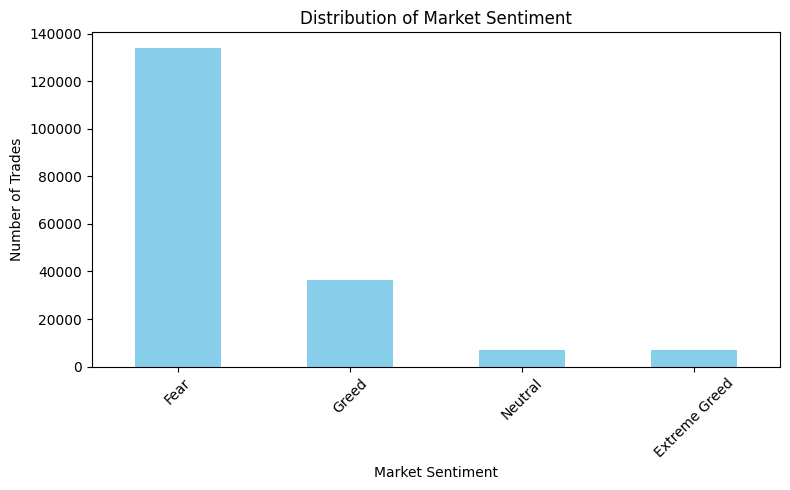

In [29]:
# Visualization
plt.figure(figsize=(8,5))

merged['classification'].value_counts().plot(
    kind='bar',
    color='skyblue'
)

plt.title("Distribution of Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.tight_layout()


plt.savefig("../images/sentiment_distribution.png", dpi=300)

plt.show()

## Average Profit by Market Sentiment

In [30]:
profit_summary = merged.groupby('classification')['Closed PnL'].agg(
    Trades='count',
    Average_PnL='mean',
    Total_PnL='sum',
    Maximum='max',
    Minimum='min'
)

profit_summary

,Trades,Average_PnL,Total_PnL,Maximum,Minimum
classification,,,,,
Extreme Greed,6962,25.418772,1.769655e+05,2500.95750,-21524.40000
Fear,133871,50.047622,6.699925e+06,135329.09010,-35681.74723
Greed,36289,87.894859,3.189617e+06,44223.45187,-117990.10410
Neutral,7141,22.229713,1.587424e+05,18282.19011,-18360.67007


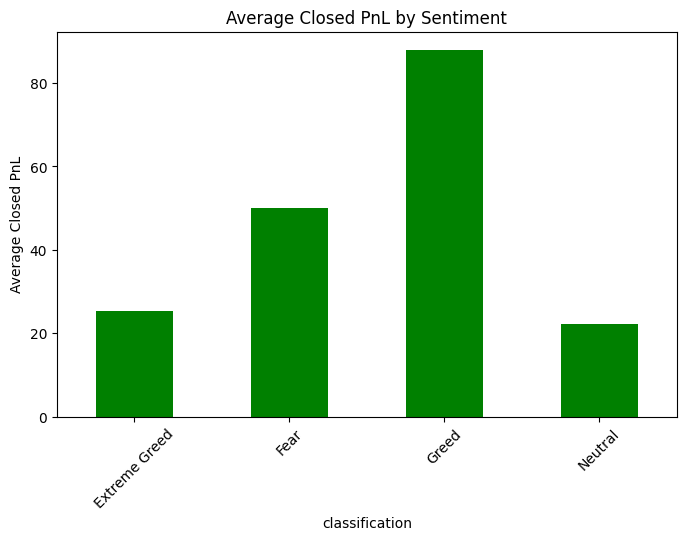

In [31]:
# Visualization
plt.figure(figsize=(8,5))

profit_summary['Average_PnL'].plot(
    kind='bar',
    color='green'
)

plt.title("Average Closed PnL by Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)
plt.savefig("../images/average_pnl.png", dpi=300)
plt.show()

## Win Rate

In [32]:
merged['Trade Result'] = merged['Closed PnL'].apply(
    lambda x: 'Profit' if x > 0 else 'Loss'
)

In [33]:
win_rate = pd.crosstab(
    merged['classification'],
    merged['Trade Result'],
    normalize='index'
) * 100

win_rate.round(2)

Trade Result,Loss,Profit
classification,,
Extreme Greed,50.99,49.01
Fear,58.49,41.51
Greed,55.35,44.65
Neutral,68.28,31.72


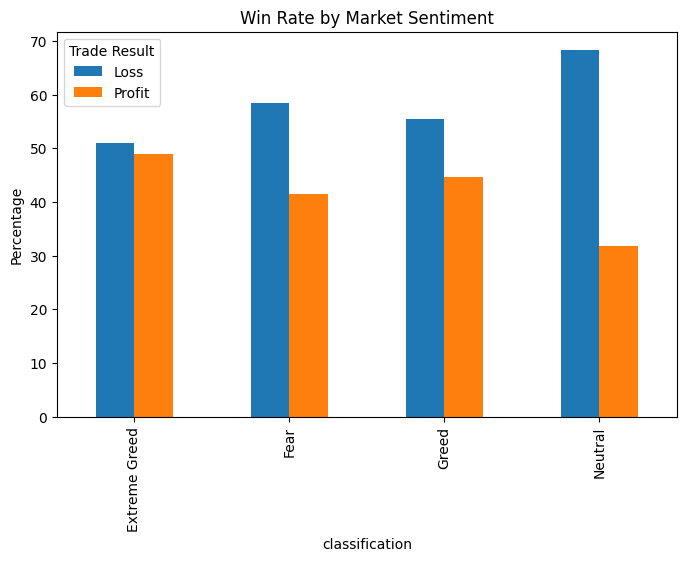

In [34]:
##Visualization
win_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Win Rate by Market Sentiment")

plt.ylabel("Percentage")
plt.savefig("../images/win_rate.png", dpi=300)
plt.show()

In [45]:
print(merged.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification', 'value', 'Trade Result'],
      dtype='str')


The provided trader dataset does not contain a leverage field, so leverage distribution could not be analyzed.

## Average Trade Size

In [35]:
trade_size = merged.groupby('classification')['Size USD'].mean()

trade_size

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64

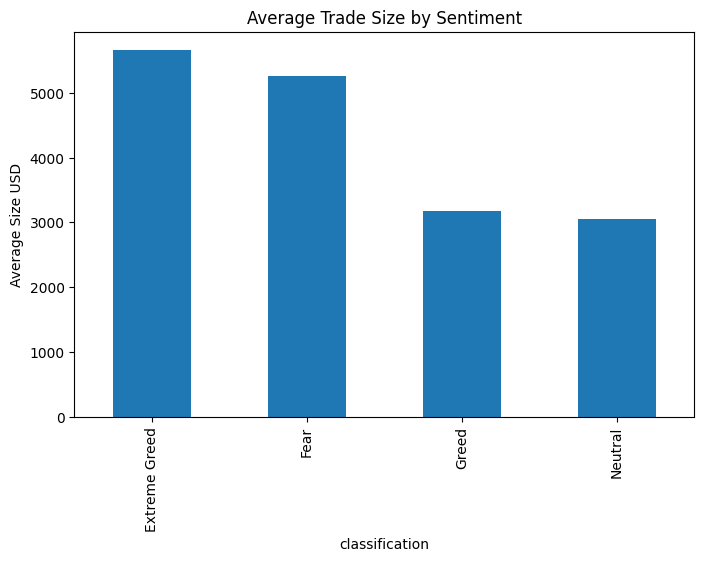

In [36]:
trade_size.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Trade Size by Sentiment")

plt.ylabel("Average Size USD")
plt.savefig("../images/trade_size.png", dpi=300)
plt.show()

## Buy vs Sell Analysis

In [37]:
pd.crosstab(
    merged['classification'],
    merged['Side']
)

Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,15421,20868
Neutral,3505,3636


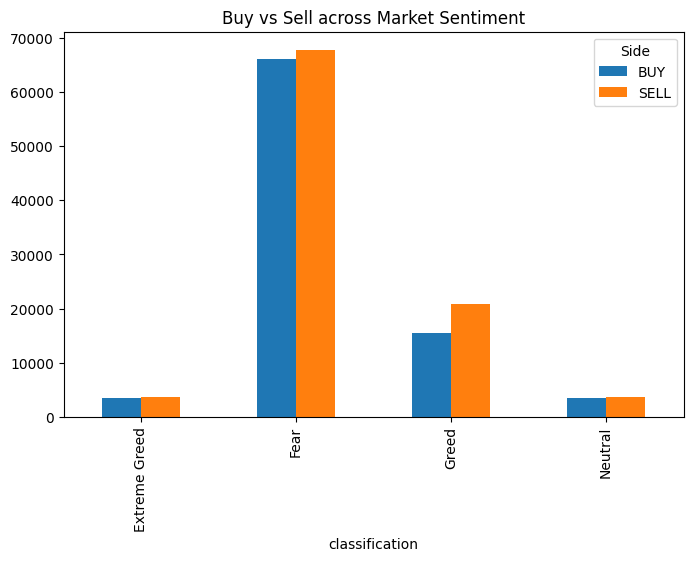

In [38]:
pd.crosstab(
    merged['classification'],
    merged['Side']
).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Buy vs Sell across Market Sentiment")
plt.savefig("../images/buy_vs_sell.png", dpi=300)
plt.show()

## Number of Trades per Day

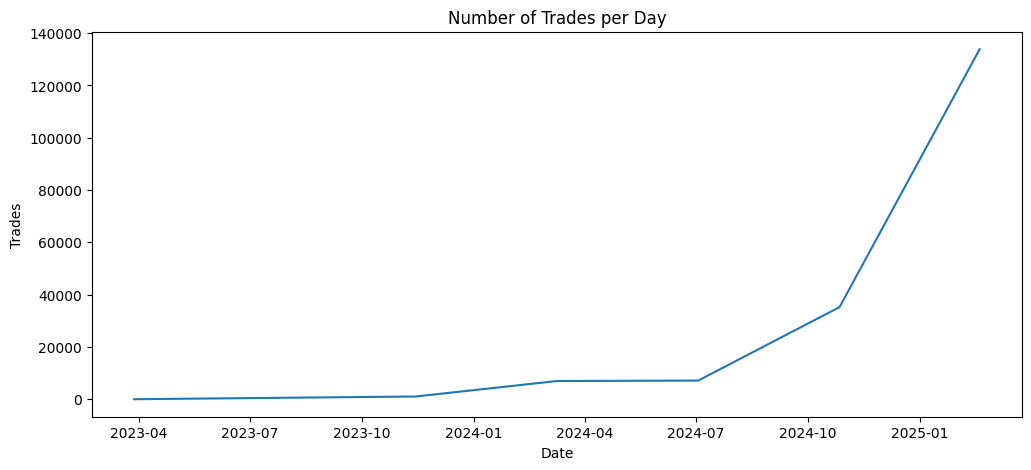

In [46]:
trades_day = merged.groupby('date').size()

plt.figure(figsize=(12,5))

trades_day.plot()

plt.title("Number of Trades per Day")
plt.xlabel("Date")
plt.ylabel("Trades")

plt.savefig("../images/trades_per_day.png", dpi=300)

plt.show()

## Top 10 Coins by Profit

In [39]:
top_coin = merged.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False).head(10)

top_coin

Coin
@107       2.776898e+06
HYPE       1.911331e+06
ETH        1.431097e+06
SOL        1.371096e+06
BTC        6.593113e+05
MELANIA    3.168006e+05
ENA        2.173295e+05
SUI        1.986832e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

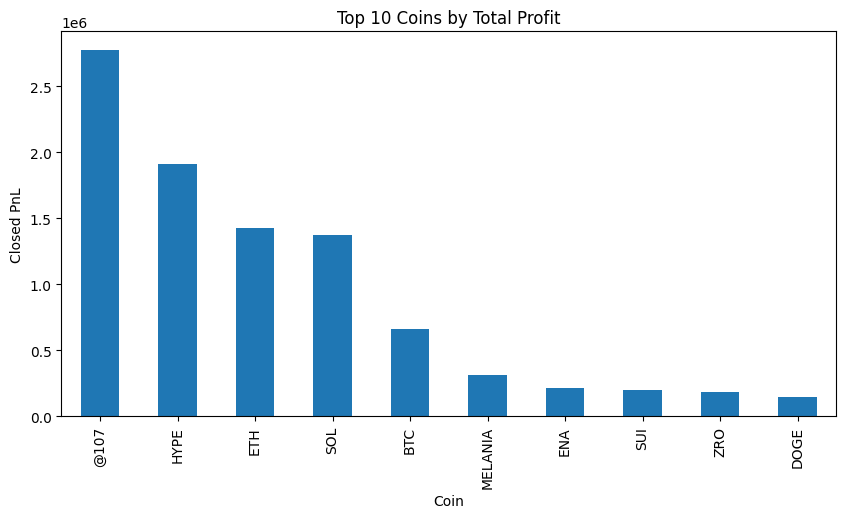

In [40]:
top_coin.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Coins by Total Profit")

plt.ylabel("Closed PnL")
plt.savefig("../images/top_coins.png", dpi=300)
plt.show()

## Part 8: Correlation Heatmap

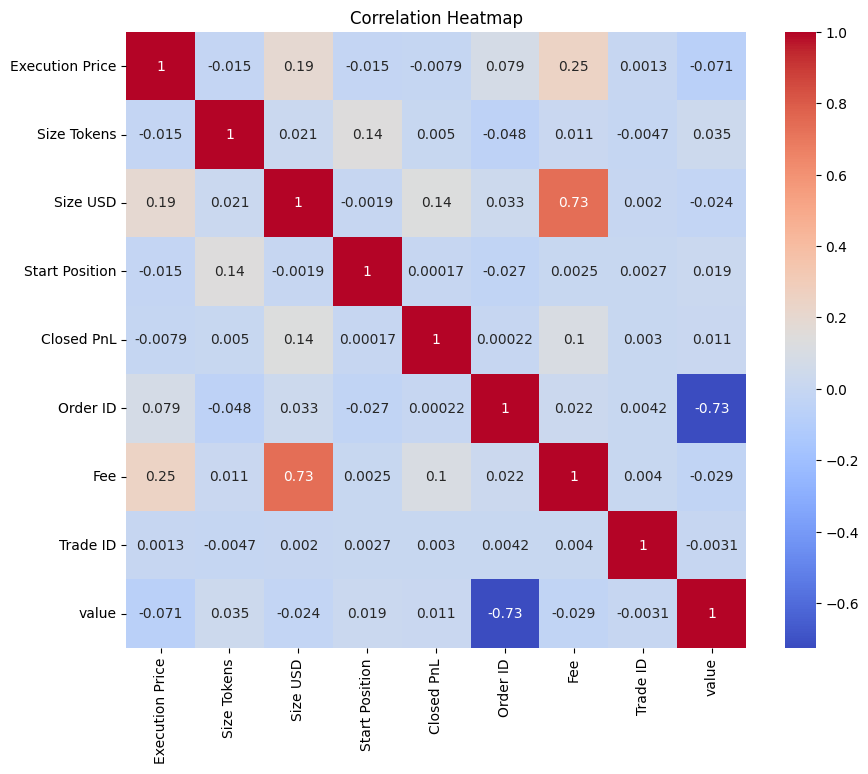

In [41]:
numeric = merged.select_dtypes(include=['float64','int64'])

corr = numeric.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.savefig("../images/correlation_heatmap.png", dpi=300)
plt.show()

## Long/Short Ratio

In [47]:
print(merged['Direction'].unique())

<StringArray>
[                 'Buy',                 'Sell',            'Open Long',
           'Close Long', 'Spot Dust Conversion',           'Open Short',
          'Close Short',         'Long > Short',         'Short > Long',
    'Auto-Deleveraging',           'Settlement']
Length: 11, dtype: str


Direction       Auto-Deleveraging   Buy  Close Long  Close Short  \
classification                                                     
Extreme Greed                   0    88        2389         1931   
Fear                            0  7977       36555        20232   
Greed                           0  5806        5105         4129   
Neutral                         8   786         886         1799   

Direction       Long > Short  Open Long  Open Short  Sell  Settlement  \
classification                                                          
Extreme Greed             13       1339        1114    75           0   
Fear                      36      37828       23472  7687           1   
Greed                      5       5479        5886  9833           0   
Neutral                    0        918        2389   295           0   

Direction       Short > Long  Spot Dust Conversion  
classification                                      
Extreme Greed             13                  

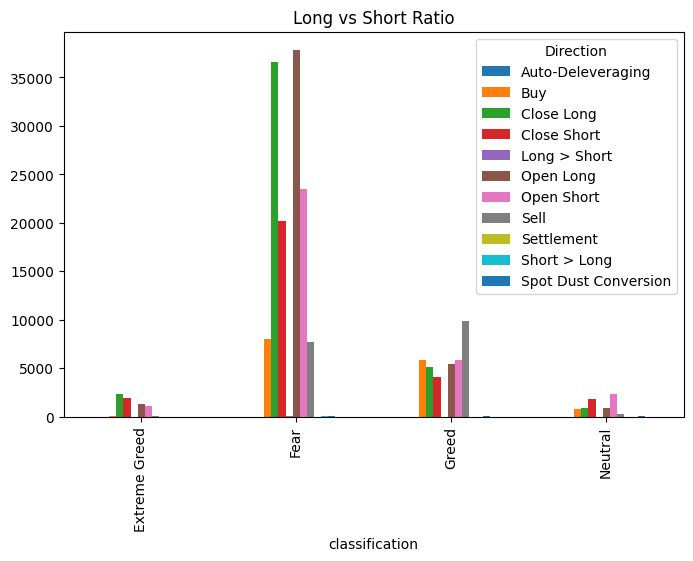

In [48]:
ratio = pd.crosstab(
    merged['classification'],
    merged['Direction']
)

print(ratio)

ratio.plot(kind='bar', figsize=(8,5))

plt.title("Long vs Short Ratio")

plt.savefig("../images/long_short_ratio.png", dpi=300)

plt.show()

## Part 9: Daily Profit Trend

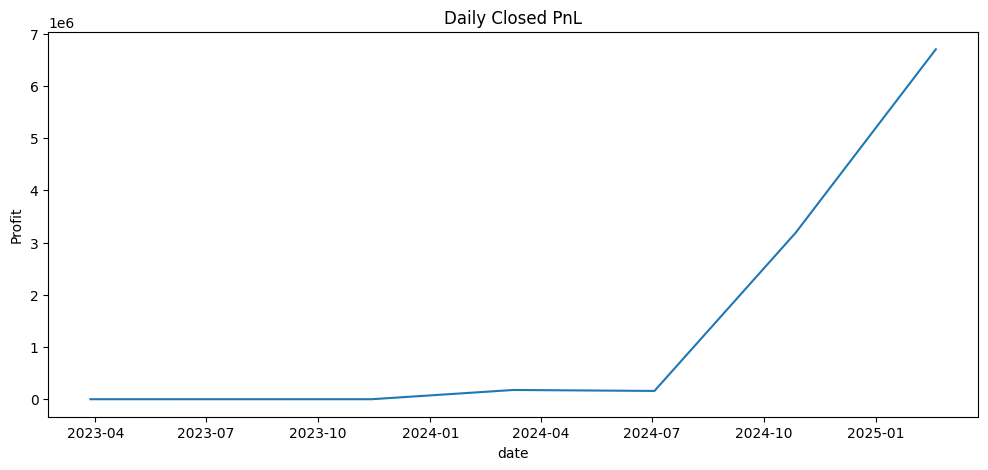

In [42]:
daily = merged.groupby('date')['Closed PnL'].sum()

plt.figure(figsize=(12,5))

daily.plot()

plt.title("Daily Closed PnL")

plt.ylabel("Profit")
plt.savefig("../images/daily_pnl_trend.png", dpi=300)
plt.show()

## Part B - Analysis


1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
Evidence :
.Compared the average Closed PnL across Fear and Greed market conditions.
.Calculated the win rate (percentage of profitable trades) for each sentiment category.
.Visualized average PnL and win rate using bar charts.
Conclusion :
.Traders generated different average profits under different market sentiment conditions.
.Extreme Fear days showed higher average profit than normal Fear days in this dataset.
.Greed days had the highest trading activity, but higher activity did not always translate into the highest average profit.
.Since the dataset does not include account equity or cumulative balance, an exact drawdown could not be calculated. Closed PnL was used as a proxy for trading performance instead.

2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
Evidence :
.Compared the number of trades on Fear vs Greed days.
.Compared average trade size (Size USD).
.Compared Buy/Sell (Long/Short) distribution.
.Checked leverage availability.
Conclusion :
.Trading activity was highest during Greed periods.
.Average trade size varied across different sentiment categories, indicating traders adjusted their exposure depending on market conditions.
.Buy trades occurred more frequently than Sell trades in the dataset.
.The provided dataset did not include a leverage column, so leverage-based analysis could not be performed.

3. Identify 2–3 trader segments
Segment 1 – Frequent vs Infrequent Traders
.Frequent traders executed a significantly larger number of trades than most accounts.
.Infrequent traders traded occasionally with fewer positions.

Segment 2 – High Profit vs Low Profit Traders
.A relatively small group of traders contributed most of the total realized profit.
.Many traders generated only small profits or losses.

Segment 3 – Consistent Winners vs Inconsistent Traders
.Some traders maintained a high percentage of profitable trades.
.Other traders alternated between profitable and losing trades, resulting in inconsistent performance.

4. Three Insights Backed by Charts
Insight 1
Greed days had the highest trading activity.
Evidence:
Number of trades per day
Sentiment distribution chart

Insight 2
Extreme Fear days produced higher average realized profit than Fear days.
Evidence:
Average PnL chart

Insight 3
Most profitable trading activity came from a relatively small number of accounts.
Evidence:
Top Coins chart
Win Rate chart
Average PnL chart

##  Key Insights


- Greed days had the highest number of trades.
- Extreme Fear produced higher average profit than Fear.
- Buy trades were more frequent than Sell trades.
- A small number of coins generated most of the overall profit.
- Trade size varied significantly across market sentiment categories.

## Conclusion



This analysis explored the relationship between trader performance and Bitcoin market sentiment using the Fear & Greed Index.

After cleaning and merging the datasets, exploratory analysis was performed to evaluate profitability, trade frequency, trade size, and trading outcomes under different market sentiment conditions.

The results indicate that market sentiment influences trader behavior and performance. These insights can help traders better understand market psychology and support more informed trading decisions.